In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Son test scriptinin ürettiği tabloyu oku
results = pd.read_csv("../reports/tables/if_mixed_results.csv")
results.head()


,index,Destination Port,Flow Duration,Total Fwd Packets,Total Length of Fwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Bwd Packet Length Max,Bwd Packet Length Min,...,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Max,Active Min,true_label,pred_label,anomaly_score
0,33553,443,262872,6,352,208,0,58.666667,1460,0,...,8192,60,5,20,0.0,0,0,0,0,0.098069
1,9427,443,6002296,7,315,233,0,45.000000,145,0,...,29200,110,3,32,292734.0,292734,292734,0,0,0.078768
2,199,443,188973,8,550,197,0,68.750000,1410,0,...,8192,115,7,20,0.0,0,0,0,0,0.096931
3,12447,53,143592,1,51,51,51,51.000000,155,155,...,-1,-1,0,20,0.0,0,0,0,0,0.137295
4,39489,80,16115609,10,1478,739,0,147.800000,596,0,...,29200,16384,2,32,615756.0,615756,615756,0,0,0.031656


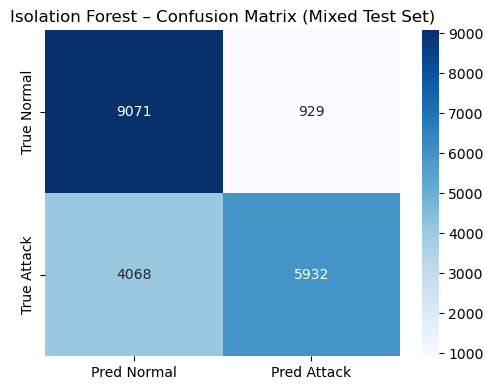

In [2]:
# Confusion matrix'i yeniden çiz (sadece kontrol için)
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(results["true_label"], results["pred_label"])
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pred Normal", "Pred Attack"],
            yticklabels=["True Normal", "True Attack"])
plt.title("Isolation Forest – Confusion Matrix (Mixed Test Set)")
plt.tight_layout()
plt.show()


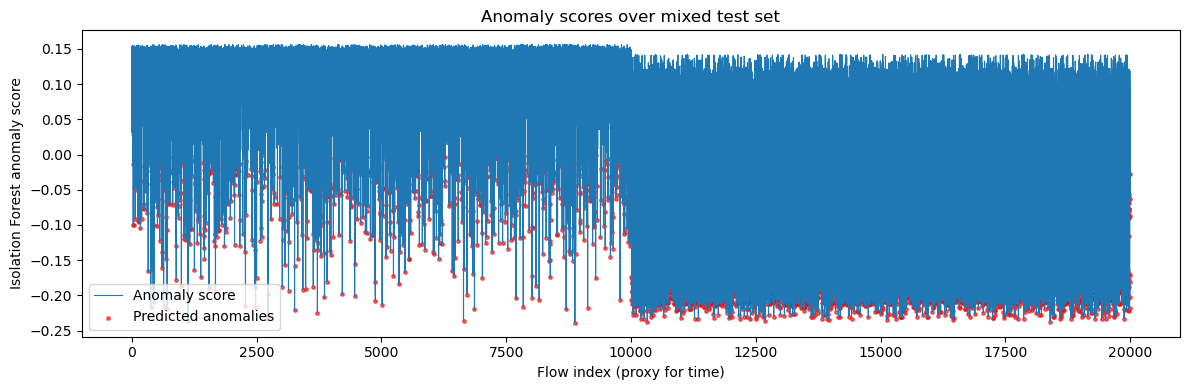

In [3]:
# Zaman içinde anomaly score (index ~ zaman)
plt.figure(figsize=(12, 4))
idx = range(len(results))
plt.plot(idx, results["anomaly_score"], label="Anomaly score", linewidth=0.8)

anomaly_idx = results.index[results["pred_label"] == 1]
plt.scatter(anomaly_idx,
            results.loc[anomaly_idx, "anomaly_score"],
            color="red", s=6, alpha=0.6,
            label="Predicted anomalies")

plt.xlabel("Flow index (proxy for time)")
plt.ylabel("Isolation Forest anomaly score")
plt.title("Anomaly scores over mixed test set")
plt.legend(loc="best")
plt.tight_layout()
plt.show()


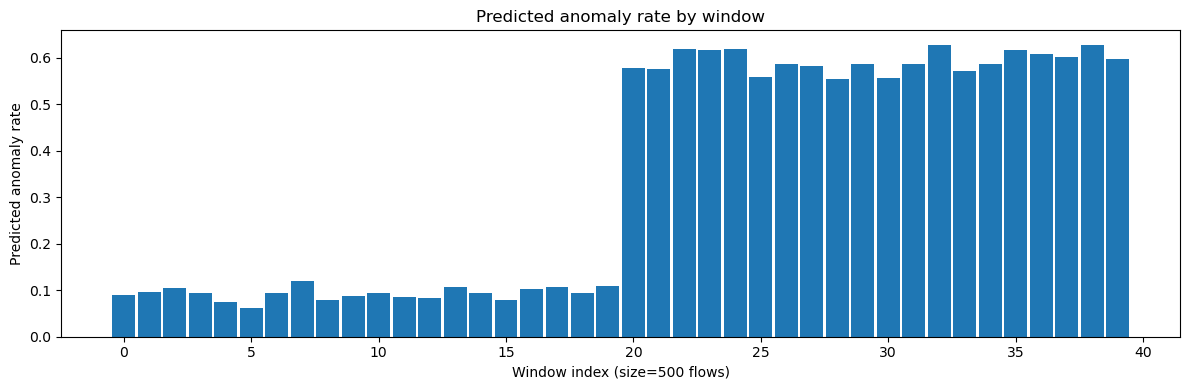

In [4]:
# Pencere bazlı alarm yoğunluğu (her 500 flow)
import numpy as np

window_size = 500
idx = np.arange(len(results))
window_ids = idx // window_size

window_df = (
    pd.DataFrame({
        "window": window_ids,
        "is_anomaly": results["pred_label"],
    })
    .groupby("window")
    .agg(anomaly_rate=("is_anomaly", "mean"), count=("is_anomaly", "size"))
    .reset_index()
)

plt.figure(figsize=(12, 4))
plt.bar(window_df["window"], window_df["anomaly_rate"], width=0.9)
plt.xlabel(f"Window index (size={window_size} flows)")
plt.ylabel("Predicted anomaly rate")
plt.title("Predicted anomaly rate by window")
plt.tight_layout()
plt.show()
